In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
from google.colab import files
uploaded = files.upload()

print(uploaded.keys())

Saving IMDB Dataset.csv to IMDB Dataset (3).csv
dict_keys(['IMDB Dataset (3).csv'])


In [7]:
df = pd.read_csv("IMDB Dataset (1).csv")

In [9]:
df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

In [10]:
X = df['clean_review']
y = df['sentiment']

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.8922
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Confusion Matrix

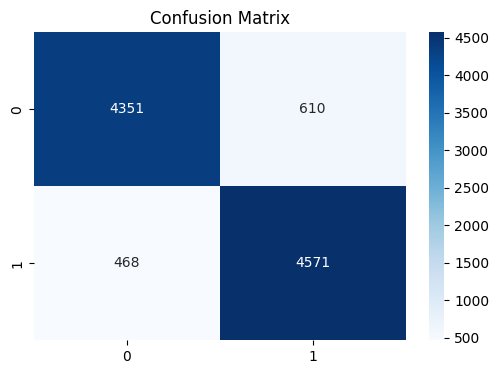

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

Sentiment Distribution

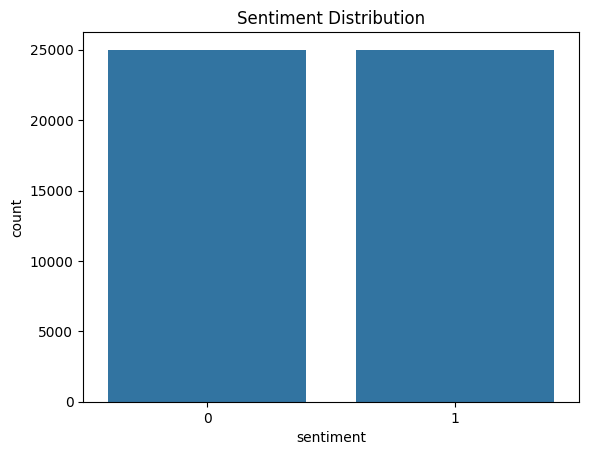

In [15]:
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

Custom Prediction

In [16]:
review = ["This movie was excellent and very entertaining"]

review_vector = vectorizer.transform(review)

prediction = model.predict(review_vector)

if prediction[0] == 1:
    print("Positive Sentiment")
else:
    print("Negative Sentiment")

Positive Sentiment


In [17]:
print("INSIGHTS")
print("1. Successfully performed sentiment analysis using NLP.")
print("2. Text preprocessing improved data quality.")
print("3. TF-IDF converted text into numerical features.")
print("4. Logistic Regression achieved strong performance.")
print("5. Positive and negative reviews were classified effectively.")
print("6. NLP can be used for opinion mining and customer feedback analysis.")

INSIGHTS
1. Successfully performed sentiment analysis using NLP.
2. Text preprocessing improved data quality.
3. TF-IDF converted text into numerical features.
4. Logistic Regression achieved strong performance.
5. Positive and negative reviews were classified effectively.
6. NLP can be used for opinion mining and customer feedback analysis.
